
The objective is to see the most basic equations of potential energy dependent on the Kepplerian orbit radius. Like Effective potential and so on...
---



Martin Ardila:

document made to show up the classification of orbtis int

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from ipywidgets import interact, FloatSlider
from scipy.optimize import fsolve
from scipy.constants import G

In [ ]:
def V_efforbit(r, l, k=5, m=1):
    return -k / r + l**2 / (2 * m * r**2)

def plot_potential(l=1.0, k=5.0, m=1.0):
    r = np.linspace(0.1, 10, 500)
    V = V_efforbit(r, l, k, m)

    plt.figure(figsize=(8, 5))
    plt.plot(r, V, label=fr'$V(r) = -\frac{{{k}}}{{r}} + \frac{{{l}^2}}{{2 \cdot {m} \cdot r^2}}$')
    plt.xlabel('r (m)')
    plt.ylabel(r'$V(r)$ (J)')
    plt.title('Potencial efectivo con parámetros ajustables')
    plt.grid(True)
    plt.ylim(-10, 20)
    plt.legend()
    plt.show()

interact(plot_potential,
         l=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='l'),
         k=FloatSlider(min=0.1, max=10.0, step=0.1, value=5.0, description='k'),
         m=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='m'))

interactive(children=(FloatSlider(value=1.0, description='l', max=5.0, min=0.1), FloatSlider(value=5.0, descri…

<function __main__.plot_potential(l=1.0, k=5.0, m=1.0)>

In [ ]:
#For The equivalent one-dimensional potential for a linear restoring force
def V_eff(r, l, k=1, m=1):
    return 0.5 * k * r**2 + l**2 / (2 * m * r**2)

def plot_potential(l=1.0, k=1.0, m=1.0):
    r = np.linspace(0.1, 10, 500)
    V = V_eff(r, l, k, m)

    plt.figure(figsize=(8, 5))
    plt.plot(r, V, label=fr'$V(r) = \frac{{1}}{{2}}{k}r^2 + \frac{{{l}^2}}{{2 \cdot {m} \cdot r^2}}$')
    plt.xlabel('r (m)')
    plt.ylabel(r'$V(r)$ (J)')
    plt.title('Potencial efectivo con fuerza restauradora lineal')
    plt.grid(True)
    plt.ylim(0, 20)
    plt.legend()
    plt.show()

interact(plot_potential,
         l=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='l'),
         k=FloatSlider(min=0.1, max=10.0, step=0.1, value=1.0, description='k'),
         m=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='m'))

interactive(children=(FloatSlider(value=1.0, description='l', max=5.0, min=0.1), FloatSlider(value=1.0, descri…

<function __main__.plot_potential(l=1.0, k=1.0, m=1.0)>

EFFECTIVE POTENTIAL FOR A COMET

In [ ]:
def plot_energy_cases_interactive(l=1.0, k=5.0, m=1.0):
    r = np.linspace(0.1, 10, 1000)
    V = V_efforbit(r, l, k, m)

    E_pos = 2
    E_neg = -1
    E_min = np.min(V)
    r_min_index = np.argmin(V)
    r_circular = r[r_min_index]

    turning_indices = np.where(np.diff(np.sign(V - E_neg)))[0]
    r_turning_points = r[turning_indices]

    plt.figure(figsize=(10, 6))
    plt.plot(r, V, label=r'$U_{\mathrm{eff}}(r)$', color='blue')
    plt.axhline(E_pos, color='red', linestyle='--', label=r'$E > 0$')
    plt.axhline(E_neg, color='green', linestyle='--', label=r'$E < 0$')
    plt.axhline(E_min, color='purple', linestyle='--', label=r'$E = U_{\mathrm{eff,min}}$')

    for rt in r_turning_points:
        plt.axvline(x=rt, color='gray', linestyle=':', alpha=0.7)
        plt.text(rt, E_neg - 1.5, f"$r_{{tp}} \\approx {rt:.2f}$", rotation=90, ha='center')

    plt.axvline(r_circular, color='purple', linestyle=':', alpha=0.7)
    plt.text(r_circular, E_min - 1.5, f"$r_c \\approx {r_circular:.2f}$", rotation=90, ha='center')

    plt.xlabel('r')
    plt.ylabel('Energy')
    plt.title('Effective Potential $U_{eff}(r)$ with Energy Configurations')
    plt.grid(True)
    plt.legend()
    plt.ylim(-10, 10)
    plt.xlim(0, 10)
    plt.tight_layout()
    plt.show()

interact(plot_energy_cases_interactive,
         l=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='l'),
         k=FloatSlider(min=0.1, max=10.0, step=0.1, value=5.0, description='k'),
         m=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='m'))


interactive(children=(FloatSlider(value=1.0, description='l', max=5.0, min=0.1), FloatSlider(value=5.0, descri…

<function __main__.plot_energy_cases_interactive(l=1.0, k=5.0, m=1.0)>

In [ ]:
def plot_orbit_with_energy(E=0.0, l=1.0, k=5.0, m=1.0):
    r = np.linspace(0.1, 10, 1000)
    V = V_efforbit(r, l, k, m)

    E_min = np.min(V)
    r_circular = r[np.argmin(V)]

    # puntos de retorno de energia
    turning_indices = np.where(np.diff(np.sign(V - E)))[0]
    r_turning_points = r[turning_indices]

    plt.figure(figsize=(10, 6))
    plt.plot(r, V, label=r'$U_{\mathrm{eff}}(r)$', color='blue')
    plt.axhline(E, color='orange', linestyle='--', label=fr'$E = {E:.2f}$')
    plt.axhline(E_min, color='purple', linestyle=':', label=r'$U_{\min}$')

    # marca de los puntos de retorno
    for i, rt in enumerate(r_turning_points):
        plt.axvline(x=rt, color='gray', linestyle=':', alpha=0.7)
        label = r"$r_{\min}$" if i == 0 else r"$r_{\max}$"
        plt.text(rt, E - 1.5, f"{label} ≈ {rt:.2f}", rotation=90, ha='center')

    # Tipo de orbita
    if E > E_min:
        if len(r_turning_points) == 0:
            orbit_type = "Unbounded orbit"
        else:
            orbit_type = "Bounded orbit"
    elif np.isclose(E, E_min, atol=1e-2):
        orbit_type = "Circular orbit"
    else:
        orbit_type = "Bounded orbit"

    # orbita circular
    if orbit_type == "Circular orbit":
        plt.axvline(x=r_circular, color='purple', linestyle='--', alpha=0.7)
        plt.text(r_circular, E_min - 1.5, f"$r_c$ ≈ {r_circular:.2f}", rotation=90, ha='center')

    plt.title(f"Effective Potential with {orbit_type}")
    plt.xlabel('r')
    plt.ylabel('Energy')
    plt.grid(True)
    plt.legend()
    plt.ylim(-10, 10)
    plt.xlim(0, 10)
    plt.tight_layout()
    plt.show()

interact(plot_orbit_with_energy,
         E=FloatSlider(min=-10, max=5, step=0.1, value=-1.0, description='E'),
         l=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='l'),
         k=FloatSlider(min=0.1, max=10.0, step=0.1, value=5.0, description='k'),
         m=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='m'))

interactive(children=(FloatSlider(value=-1.0, description='E', max=5.0, min=-10.0), FloatSlider(value=1.0, des…

<function __main__.plot_orbit_with_energy(E=0.0, l=1.0, k=5.0, m=1.0)>

KEPPLER ORBITS


In [ ]:
def kepler_orbit(l=1.0, A=0.5, gamma=1.0, mu=1.0):
    # Define constants
    c = l**2 / (gamma * mu)
    epsilon = A * l**2 / (gamma * mu)

    # Angular range
    phi = np.linspace(0, 2 * np.pi, 1000)

    # r(phi)
    r = c / (1 - epsilon * np.cos(phi))

    x = r * np.cos(phi)
    y = r * np.sin(phi)

    # Plot
    plt.figure(figsize=(6,6))
    plt.plot(x, y, label=f"ε = {epsilon:.2f}")
    plt.plot(0, 0, 'yo', label="Center of Force")
    plt.axis('equal')
    plt.grid(True)
    plt.title("Kepler Orbit")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()

# Interactive sliders
interact(
    kepler_orbit,
    l=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='l'),
    A=FloatSlider(min=0.0, max=5.0, step=0.1, value=0.5, description='A'),
    gamma=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='γ'),
    mu=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='μ')
)

interactive(children=(FloatSlider(value=1.0, description='l', max=5.0, min=0.1), FloatSlider(value=0.5, descri…

<function __main__.kepler_orbit(l=1.0, A=0.5, gamma=1.0, mu=1.0)>

In [ ]:
def radial_oscillation(l=1.0, A=0.5, gamma=1.0, mu=1.0):
    # Constants
    #gamma es la fuerza cte reducidad, por ejm Gm1m2
    c = l**2 / (gamma * mu)
    epsilon = A * l**2 / (gamma * mu)

    # Angular range
    phi = np.linspace(0, 2 * np.pi, 1000)

    # Radial distance
    r = c / (1 - epsilon * np.cos(phi))

    r_max = r + epsilon
    r_min = r - epsilon

    # Plot r(phi) and envelope
    plt.figure(figsize=(8, 4))
    plt.plot(phi, r, label="r(ϕ)", color='blue')
    plt.plot(phi, r_max, '--', color='red', label="r + ε")
    plt.plot(phi, r_min, '--', color='green', label="r - ε")
    plt.fill_between(phi, r_min, r_max, color='gray', alpha=0.2, label='Oscillation band')

    plt.xlabel("ϕ (radians)")
    plt.ylabel("r(ϕ)")
    plt.title("Radial Oscillation of Kepler Orbit")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Interactive sliders
interact(
    radial_oscillation,
    l=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='l'),
    A=FloatSlider(min=0.0, max=5.0, step=0.1, value=0.5, description='A'), #constante de integracion que sale de resolver eq dif de segundo orden
    gamma=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='γ'),
    mu=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='μ')
)

interactive(children=(FloatSlider(value=1.0, description='l', max=5.0, min=0.1), FloatSlider(value=0.5, descri…

<function __main__.radial_oscillation(l=1.0, A=0.5, gamma=1.0, mu=1.0)>

In [ ]:
def plot_denominator(l=1.0, A=0.5, gamma=1.0, mu=1.0):
    # Calcula epsilon dinámicamente
    epsilon = A * l**2 / (gamma * mu)

    # Rango angular
    phi = np.linspace(0, 2 * np.pi, 1000)

    # Denominador
    denom = 1 + epsilon * np.cos(phi)

    # Gráfica
    plt.figure(figsize=(8, 4))
    plt.plot(phi, denom, label=fr"$1 + \varepsilon \cos(\phi)$", color='black')
    plt.axhline(1 + epsilon, color='black', linestyle='--', label=r"$1 \pm \varepsilon$")
    plt.axhline(1 - epsilon, color='black', linestyle='--')
    plt.xticks([0, np.pi, 2 * np.pi], [r"$0$", r"$\pi$", r"$2\pi$"])
    plt.yticks([1 - epsilon, 1, 1 + epsilon],
               [fr"$1 - \varepsilon$", r"$1$", fr"$1 + \varepsilon$"])
    plt.xlabel(r"$\phi$")
    plt.ylabel("Denominator")
    plt.title(r"Denominator $1 + \varepsilon \cos(\phi)$ vs $\phi$")
    plt.ylim(1 - 1.1 * abs(epsilon), 1 + 1.1 * abs(epsilon))  # Margen visual
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Widgets interactivos
interact(
    plot_denominator,
    l=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='l'),
    A=FloatSlider(min=0.0, max=5.0, step=0.1, value=0.5, description='A'),
    gamma=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='γ'),
    mu=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='μ')
)

interactive(children=(FloatSlider(value=1.0, description='l', max=5.0, min=0.1), FloatSlider(value=0.5, descri…

<function __main__.plot_denominator(l=1.0, A=0.5, gamma=1.0, mu=1.0)>

In [ ]:
def plot_energy(gamma=1.0, mu=1.0, ell=1.0):
    # Eccentricity range: from 0 to 2 (includes bounded & unbounded)
    epsilon = np.linspace(0, 2, 500)

    # Energy from equation (8.58)
    E = (gamma**2 * mu / (2 * ell**2)) * (epsilon**2 - 1)

    # Plot
    plt.figure(figsize=(8, 4))
    plt.plot(epsilon, E, label=r"$E = \frac{\gamma^2 \mu}{2 \ell^2}(\varepsilon^2 - 1)$", color='blue')
    plt.axhline(0, color='black', linestyle='--')

    # Mark region types
    plt.fill_between(epsilon, E, 0, where=(epsilon < 1), color='green', alpha=0.1, label='Bounded orbits ($E<0$)')
    plt.fill_between(epsilon, E, 0, where=(epsilon > 1), color='red', alpha=0.1, label='Unbounded orbits ($E>0$)')

    plt.xlabel(r"Eccentricity $\varepsilon$")
    plt.ylabel("Energy $E$")
    plt.title("Orbital Energy vs. Eccentricity")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Interactive sliders
interact(
    plot_energy,
    gamma=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='γ'),
    mu=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='μ'),
    ell=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='ℓ')
)

interactive(children=(FloatSlider(value=1.0, description='γ', max=5.0, min=0.1), FloatSlider(value=1.0, descri…

<function __main__.plot_energy(gamma=1.0, mu=1.0, ell=1.0)>

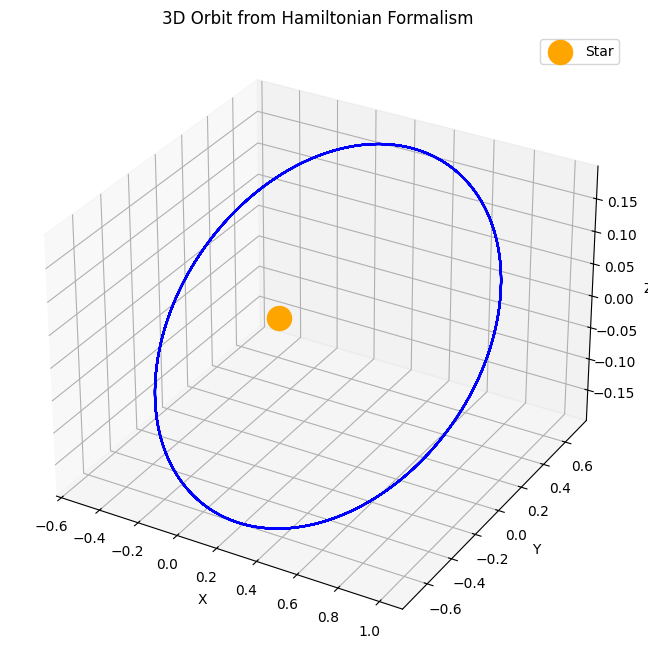

In [ ]:
G = 1.0        # Gravitational constant in chosen units
M = 1.0        # Mass of central star
m = 1.0        # Mass of planet

def hamiltonian(t, y):
    """
    y = [x, y, z, px, py, pz]
    Returns dydt
    """
    x, y_, z, px, py, pz = y
    r = np.sqrt(x**2 + y_**2 + z**2)

    dxdt = px / m
    dydt = py / m
    dzdt = pz / m

    dp_x_dt = -G * M * m * x / r**3
    dp_y_dt = -G * M * m * y_ / r**3
    dp_z_dt = -G * M * m * z / r**3

    return [dxdt, dydt, dzdt, dp_x_dt, dp_y_dt, dp_z_dt]

# Initial conditions: position and momentum
x0 = 1.0
y0 = 0.0
z0 = 0.0

vx0 = 0.0
vy0 = 0.8   # try 0.8 for elliptical, sqrt(GM/r) ~ 1 for circular
vz0 = 0.2

px0 = m * vx0
py0 = m * vy0
pz0 = m * vz0

y_init = [x0, y0, z0, px0, py0, pz0]

# Time span
t_span = (0, 50)
t_eval = np.linspace(t_span[0], t_span[1], 5000)

# Integrate
sol = solve_ivp(hamiltonian, t_span, y_init, t_eval=t_eval, rtol=1e-9, atol=1e-9)

# Plot
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(sol.y[0], sol.y[1], sol.y[2], color='b')

# Draw central star
ax.scatter([0], [0], [0], color='orange', s=300, label='Star')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Orbit from Hamiltonian Formalism')
ax.legend()
plt.show()